In [1]:
#Esta fase de análisis del dato se desarrolla en un entorno independiente, partiendo del dataset analítico final generado en la fase previa de ingeniería del dato.
#con el fin de garantizar reproducibilidad y separación clara entre preparación y modelización

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme()

In [4]:
base = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD")
processed = base / "data" / "processed"
tables = base / "outputs" / "tables"
graficos = base / "outputs" / "graficos"

print(processed)

C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed


In [5]:
df = pd.read_csv(processed / "samur_analitico_final_entrega.csv")

In [6]:
df_modelado = df.copy()

In [7]:
#dimensión del dataset
df_modelado.shape

(30456, 25)

In [8]:
df_modelado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30456 entries, 0 to 30455
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   anio                                 30456 non-null  int64  
 1   asistencia_para_si_mismo             30444 non-null  float64
 2   cree_necesaria_formacion_ciudadania  28429 non-null  float64
 3   edad                                 30455 non-null  float64
 4   genero                               30456 non-null  object 
 5   hubo_segundo_contacto                30179 non-null  float64
 6   id_registro                          30456 non-null  int64  
 7   lugar_llamada                        30456 non-null  object 
 8   op1_amabilidad                       28305 non-null  float64
 9   op1_rapidez                          29426 non-null  float64
 10  op2_amabilidad                       13358 non-null  float64
 11  op2_no_aplica               

In [9]:
#resumen estadistico
df_modelado.describe()

,anio,asistencia_para_si_mismo,cree_necesaria_formacion_ciudadania,edad,hubo_segundo_contacto,id_registro,op1_amabilidad,op1_rapidez,op2_amabilidad,op2_no_aplica,...,recibio_sms_confirmacion,satisfaccion_global,satisfaccion_tiempo_llegada,sms_util,tiempo_atencion_final_seg,tiempo_llegada_final_min,indice_trato_op1,indice_trato_op2,indice_trato_total,satisfaccion_global_binaria
count,30456.000000,30444.000000,28429.000000,30455.000000,30179.000000,3.045600e+04,28305.000000,29426.000000,13358.000000,30456.000000,...,30438.000000,28161.000000,13128.000000,22070.000000,30456.000000,30456.000000,29721.000000,13584.000000,30200.000000,30456.000000
mean,2022.138364,0.099461,0.645397,45.482548,0.482521,2.746406e+07,9.108567,9.044179,9.322279,0.512773,...,0.954563,9.023188,8.338437,0.922429,98.949255,19.799301,9.075990,9.302341,9.091606,0.817310
std,0.917853,0.299285,0.478401,14.377619,0.499703,1.286669e+07,1.688749,1.756576,1.505190,0.499845,...,0.208263,1.646189,2.219317,0.267502,98.330116,10.652590,1.621494,1.470721,1.585097,0.386418
min,2021.000000,0.000000,0.000000,0.000000,0.000000,5.511425e+06,1.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,2021.000000,0.000000,0.000000,37.000000,0.000000,1.507112e+07,9.000000,9.000000,9.000000,0.000000,...,1.000000,9.000000,8.000000,1.000000,10.000000,10.000000,9.000000,9.000000,9.000000,1.000000
50%,2022.000000,0.000000,1.000000,47.000000,0.000000,3.354572e+07,10.000000,10.000000,10.000000,1.000000,...,1.000000,10.000000,9.000000,1.000000,60.000000,20.000000,10.000000,10.000000,10.000000,1.000000
75%,2023.000000,0.000000,1.000000,54.000000,1.000000,3.797384e+07,10.000000,10.000000,10.000000,1.000000,...,1.000000,10.000000,10.000000,1.000000,180.000000,30.000000,10.000000,10.000000,10.000000,1.000000
max,2023.000000,1.000000,1.000000,101.000000,1.000000,4.174883e+07,10.000000,10.000000,10.000000,1.000000,...,1.000000,10.000000,10.000000,1.000000,3600.000000,120.000000,10.000000,10.000000,10.000000,1.000000


In [10]:
#La fase de análisis del dato se inicia a partir del dataset analítico final obtenido en la etapa de ingeniería del dato, el cual contiene las variables depuradas, transformadas y seleccionadas para el modelado. 
#Se realiza una revisión inicial de la estructura del dataset, incluyendo dimensiones, tipos de variables y estadísticas descriptivas básicas, con el objetivo de validar la calidad del dato antes de proceder a la modelización.

In [11]:
#La fase de análisis del dato se inicia a partir del dataset analítico final obtenido en la etapa de ingeniería del dato, el cual contiene las variables depuradas, transformadas y seleccionadas para el modelado. 
#Se realiza una revisión inicial de la estructura del dataset, incluyendo dimensiones, tipos de variables y estadísticas descriptivas básicas, con el objetivo de validar la calidad del dato antes de proceder a la modelización.

In [13]:
#DEFINO PROBLEMA DE MODELIZACION
#mi pregunta de investigación es: "¿Qué factores del proceso de atención telefónica describen e influyen en la experiencia del solicitante en SAMUR?
#Y en qué medida pueden modelizarse para anticipar su nivel de satisfacción a partir de los datos de calidad percibida?"


#por lo que con mi modelización estará orientada a anticipar la satisfacción global del solictiante a partir de variables de calidad percibida, tiempos, trato y contexto de la llamada

In [16]:
#Para los modelos supervisados, la varibale objetivo será la satisfacción_global_binaria
#(alta satisfacción=1 y baja satisfacción=0)
#Clasificación supervisada binaria

In [19]:
#Este problema nos permite responder algo muy comprensible: 
#¿Podemos anticipar si un solicitante presentará alta saltisfacción o no"

In [20]:
#Los resultados podrán comunicar de una manera más clara 
    #1. Probabilidad de alta satisfacción
    #2. Factores que aumentan o reducen esa probabilidad

In [17]:
df_modelado["satisfaccion_global_binaria"].value_counts(dropna=False)

satisfaccion_global_binaria
1    24892
0     5564
Name: count, dtype: int64

In [18]:
tabla_objetivo = df_modelado["satisfaccion_global_binaria"].value_counts(dropna=False).reset_index()
tabla_objetivo.columns = ["satisfaccion_global_binaria", "n_registros"]
tabla_objetivo["pct"] = (tabla_objetivo["n_registros"] / tabla_objetivo["n_registros"].sum() * 100).round(2)

tabla_objetivo

,satisfaccion_global_binaria,n_registros,pct
0,1,24892,81.73
1,0,5564,18.27


In [21]:
#Hemos comprobado que la varible existe, está bien construida y la distribución tiene sentido

In [22]:
#guardo la tabla
from pathlib import Path

tables = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\tables")
tables.mkdir(parents=True, exist_ok=True)

tabla_objetivo.to_excel(tables / "analisis_tabla_variable_objetivo.xlsx", index=False)
tabla_objetivo.to_csv(tables / "analisis_tabla_variable_objetivo.csv", index=False)

print("Tabla de variable objetivo guardada")

Tabla de variable objetivo guardada


In [23]:
#El problema principal de modelización se formuló como una tarea de clasificación supervisada binaria, tomando como variable objetivo la satisfacción global binarizada del solicitante. Esta decisión permite abordar el análisis en términos de alta satisfacción frente a no alta satisfacción, facilitando la comparación entre algoritmos, la interpretación de resultados y la comunicación de conclusiones en términos operativos

In [24]:
#BREVE EXPLICACIÓN MODELOS PARA MEMORIA

#1. RESGRESIÓN LOGISTICA: 
    #Para entender que variables aumentan o reducen la probabilidad de alta satisfaccion
#2. RANDOM FOREST
    #La satisfacción no es aparentemente puramente lineal ya que es razonable que 
        #el tiempo tenga efectos umbral a aprtir de los cuales el solicitante tiene alta o baja satisfacción
        #el tratao compense parcialemnte tiempos peores
        #exista interacciones entre variables

In [25]:
#PREPARACIÓN DE LOS MODELOS
#PROBLEMA PRINCIPAL: CLASIFICACION BINARIA SUPERVISADA
#VARIABLE OBJETIVO: satisfaccion_global_binaria
# Variable objetivo
y = df_modelado["satisfaccion_global_binaria"].copy()

print("Nombre de la variable objetivo:", y.name)
print("\nDistribución:")
print(y.value_counts(dropna=False))
print("\nProporción:")
print((y.value_counts(normalize=True, dropna=False) * 100).round(2))

Nombre de la variable objetivo: satisfaccion_global_binaria

Distribución:
satisfaccion_global_binaria
1    24892
0     5564
Name: count, dtype: int64

Proporción:
satisfaccion_global_binaria
1    81.73
0    18.27
Name: proportion, dtype: float64


In [26]:
#Los modelos deben explicar/predecir la satisfacción a partir de variables que representan:
    #tiempo de respuesta
    #calidad percibida del trato
    #experiencia comunicativa
    #contexto de la llamada
    #perfil básico del solicitante


In [27]:

#Para comparar modelos:
    #Usaré un conjunto interpretable para regresión logística
    #Usaré un conjunto amplieado para Random Forest y XGBoost


In [28]:
# Var para Regresión logística

features_logistica = [
    "edad",
    "genero",
    "lugar_llamada",
    "asistencia_para_si_mismo",
    "recibio_sms_confirmacion",
    "sms_util",
    "hubo_segundo_contacto",
    "op2_no_aplica",
    "indice_trato_total",
    "tiempo_atencion_final_seg",
    "tiempo_llegada_final_min",
    "satisfaccion_tiempo_llegada",
    "anio"
]

X_log = df_modelado[features_logistica].copy()

print("Shape X_log:", X_log.shape)
X_log.head()

Shape X_log: (30456, 13)


,edad,genero,lugar_llamada,asistencia_para_si_mismo,recibio_sms_confirmacion,sms_util,hubo_segundo_contacto,op2_no_aplica,indice_trato_total,tiempo_atencion_final_seg,tiempo_llegada_final_min,satisfaccion_tiempo_llegada,anio
0,34.0,mujer,via_publica,0.0,1.0,0.0,0.0,1,6.5,10.0,5.0,3.0,2021
1,30.0,hombre,via_publica,0.0,1.0,NaN,0.0,1,10.0,10.0,10.0,10.0,2021
2,55.0,hombre,via_publica,1.0,1.0,1.0,1.0,0,10.0,10.0,5.0,10.0,2021
3,70.0,hombre,via_publica,1.0,1.0,1.0,1.0,0,10.0,10.0,15.0,10.0,2021
4,49.0,mujer,domicilio,0.0,1.0,1.0,1.0,0,8.0,20.0,20.0,7.0,2021


In [29]:
#Uso estas variables porqeu son las dimensiones centrales de mi TFG
#Perfil del solicitante: (edad y genero)
#Contexto: (lugar_llamada, asistencia_para_si_mismo, anio)
#comunicación/proceso (sms, segundo_contacto)
#trato (indice_trato_total)
#tiempo (tiempo_atencion_final_seg, tiempo_llegada_final_min)
#percepción del tiempo de llegada (satisfaccion_tiempo_llegada)


#En este modelo evito excesiva colinealidad y redundancia por lo que evitamos algunas de las variables y usamos en lugar 
#indice_trato_total que construimos en feature engineering


In [30]:
#varibales para Random Forest y XGBoost.
features_avanzadas = [
    "edad",
    "genero",
    "lugar_llamada",
    "asistencia_para_si_mismo",
    "recibio_sms_confirmacion",
    "sms_util",
    "hubo_segundo_contacto",
    "op2_no_aplica",
    "op1_amabilidad",
    "op1_rapidez",
    "op2_amabilidad",
    "op2_rapidez",
    "indice_trato_op1",
    "indice_trato_op2",
    "indice_trato_total",
    "tiempo_atencion_final_seg",
    "tiempo_llegada_final_min",
    "satisfaccion_tiempo_llegada",
    "anio"
]

X_adv = df_modelado[features_avanzadas].copy()

print("Shape X_adv:", X_adv.shape)
X_adv.head()

Shape X_adv: (30456, 19)


,edad,genero,lugar_llamada,asistencia_para_si_mismo,recibio_sms_confirmacion,sms_util,hubo_segundo_contacto,op2_no_aplica,op1_amabilidad,op1_rapidez,op2_amabilidad,op2_rapidez,indice_trato_op1,indice_trato_op2,indice_trato_total,tiempo_atencion_final_seg,tiempo_llegada_final_min,satisfaccion_tiempo_llegada,anio
0,34.0,mujer,via_publica,0.0,1.0,0.0,0.0,1,3.0,10.0,NaN,NaN,6.5,NaN,6.5,10.0,5.0,3.0,2021
1,30.0,hombre,via_publica,0.0,1.0,NaN,0.0,1,10.0,10.0,NaN,NaN,10.0,NaN,10.0,10.0,10.0,10.0,2021
2,55.0,hombre,via_publica,1.0,1.0,1.0,1.0,0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,5.0,10.0,2021
3,70.0,hombre,via_publica,1.0,1.0,1.0,1.0,0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,15.0,10.0,2021
4,49.0,mujer,domicilio,0.0,1.0,1.0,1.0,0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,20.0,20.0,7.0,2021


In [31]:
#Usamos mayor riqueza de variables para estos 2 modelos porque manejan mejor relaciones no lineales, interacciones, y cierta redundancia sin romperse como un modelo lineal
#Es más adecuado para mi problema, donde el trato, el tiempo y la comunicación pueden combinarse de forma compleja en la experiencia del solicitante

In [33]:
#MODELO NO SUPERVISADO EXTRA:
#Además del análisis supervisado orientado a la predicción de la satisfacción, se incorpora un bloque de aprendizaje no supervisado mediante clustering 
#con el objetivo de identificar perfiles diferenciados de solicitantes en función de su experiencia con el servicio

#A diferencia de los modelos supervisados, que buscan predecir una variable objetivo, el clustering permite descubrir estructuras latentes en los datos sin una variable dependiente predefinid

#A diferencia de los modelos supervisados, que buscan predecir una variable objetivo, el clustering permite descubrir estructuras latentes en los datos sin una variable dependiente predefinid

#De esta manera podré identificarf clusteres como estos ejemplos
    #Cluster 1: satisfechos aunqeu tengan espera
    #Cluster 2: Muy sensibles al tiempo
    #Cluster 3: Críticos con el trato

In [34]:
#Var para clustering ya que no usaré la var objetivo, no busco predecir la satisfacción sino buscar perfiles de experiencia
features_clustering = [
    "indice_trato_total",
    "tiempo_atencion_final_seg",
    "tiempo_llegada_final_min",
    "satisfaccion_tiempo_llegada",
    "sms_util",
    "hubo_segundo_contacto"
]

X_cluster = df_modelado[features_clustering].copy()

print("Shape X_cluster:", X_cluster.shape)
X_cluster.head()


Shape X_cluster: (30456, 6)


,indice_trato_total,tiempo_atencion_final_seg,tiempo_llegada_final_min,satisfaccion_tiempo_llegada,sms_util,hubo_segundo_contacto
0,6.5,10.0,5.0,3.0,0.0,0.0
1,10.0,10.0,10.0,10.0,NaN,0.0
2,10.0,10.0,5.0,10.0,1.0,1.0
3,10.0,10.0,15.0,10.0,1.0,1.0
4,8.0,20.0,20.0,7.0,1.0,1.0


In [35]:
#Reviso tipos de var para cada conjunto para los modelos
print("Tipos en X_log:")
print(X_log.dtypes)

print("\nTipos en X_adv:")
print(X_adv.dtypes)

print("\nTipos en X_cluster:")
print(X_cluster.dtypes)

Tipos en X_log:
edad                           float64
genero                          object
lugar_llamada                   object
asistencia_para_si_mismo       float64
recibio_sms_confirmacion       float64
sms_util                       float64
hubo_segundo_contacto          float64
op2_no_aplica                    int64
indice_trato_total             float64
tiempo_atencion_final_seg      float64
tiempo_llegada_final_min       float64
satisfaccion_tiempo_llegada    float64
anio                             int64
dtype: object

Tipos en X_adv:
edad                           float64
genero                          object
lugar_llamada                   object
asistencia_para_si_mismo       float64
recibio_sms_confirmacion       float64
sms_util                       float64
hubo_segundo_contacto          float64
op2_no_aplica                    int64
op1_amabilidad                 float64
op1_rapidez                    float64
op2_amabilidad                 float64
op2_rapidez      

In [36]:
#Separo var numéricas y categoricas
num_cols_log = X_log.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
cat_cols_log = X_log.select_dtypes(include=["object", "string", "category"]).columns.tolist()

num_cols_adv = X_adv.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
cat_cols_adv = X_adv.select_dtypes(include=["object", "string", "category"]).columns.tolist()

num_cols_cluster = X_cluster.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
cat_cols_cluster = X_cluster.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Logística - numéricas:", num_cols_log)
print("Logística - categóricas:", cat_cols_log)

print("\nAvanzadas - numéricas:", num_cols_adv)
print("Avanzadas - categóricas:", cat_cols_adv)

print("\nClustering - numéricas:", num_cols_cluster)
print("Clustering - categóricas:", cat_cols_cluster)

Logística - numéricas: ['edad', 'asistencia_para_si_mismo', 'recibio_sms_confirmacion', 'sms_util', 'hubo_segundo_contacto', 'op2_no_aplica', 'indice_trato_total', 'tiempo_atencion_final_seg', 'tiempo_llegada_final_min', 'satisfaccion_tiempo_llegada', 'anio']
Logística - categóricas: ['genero', 'lugar_llamada']

Avanzadas - numéricas: ['edad', 'asistencia_para_si_mismo', 'recibio_sms_confirmacion', 'sms_util', 'hubo_segundo_contacto', 'op2_no_aplica', 'op1_amabilidad', 'op1_rapidez', 'op2_amabilidad', 'op2_rapidez', 'indice_trato_op1', 'indice_trato_op2', 'indice_trato_total', 'tiempo_atencion_final_seg', 'tiempo_llegada_final_min', 'satisfaccion_tiempo_llegada', 'anio']
Avanzadas - categóricas: ['genero', 'lugar_llamada']

Clustering - numéricas: ['indice_trato_total', 'tiempo_atencion_final_seg', 'tiempo_llegada_final_min', 'satisfaccion_tiempo_llegada', 'sms_util', 'hubo_segundo_contacto']
Clustering - categóricas: []


In [37]:
#guardo tabla de selección de variables
tabla_variables_modelado = pd.DataFrame({
    "variable": sorted(set(features_logistica + features_avanzadas + features_clustering)),
})

tabla_variables_modelado["en_logistica"] = tabla_variables_modelado["variable"].isin(features_logistica)
tabla_variables_modelado["en_modelos_avanzados"] = tabla_variables_modelado["variable"].isin(features_avanzadas)
tabla_variables_modelado["en_clustering"] = tabla_variables_modelado["variable"].isin(features_clustering)

tabla_variables_modelado.head(30)

,variable,en_logistica,en_modelos_avanzados,en_clustering
0,anio,True,True,False
1,asistencia_para_si_mismo,True,True,False
2,edad,True,True,False
3,genero,True,True,False
4,hubo_segundo_contacto,True,True,True
5,indice_trato_op1,False,True,False
6,indice_trato_op2,False,True,False
7,indice_trato_total,True,True,True
8,lugar_llamada,True,True,False
9,op1_amabilidad,False,True,False


In [38]:
#guardo en mi carpeta
tables.mkdir(parents=True, exist_ok=True)

tabla_variables_modelado.to_excel(tables / "analisis_tabla_variables_modelado.xlsx", index=False)
tabla_variables_modelado.to_csv(tables / "analisis_tabla_variables_modelado.csv", index=False)

print("Tabla de variables de modelado guardada")

Tabla de variables de modelado guardada


In [39]:
#PASO 1: TRAIN /TEST SPLIT para entrenar modelo, evaluarlo en datos que no ha visto
from sklearn.model_selection import train_test_split

# División train-test (80%-20%)
X_train_log, X_test_log, y_train, y_test = train_test_split(
    X_log, y, test_size=0.2, random_state=42, stratify=y
)

X_train_adv, X_test_adv, _, _ = train_test_split(
    X_adv, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train_log.shape)
print("Test:", X_test_log.shape)

Train: (24364, 13)
Test: (6092, 13)


In [40]:
#stratify=y mantiene la proporcion de clases
#random_sate=42 para la reproducibilidad

#Se ha realizado una partición del dataset en conjuntos de entrenamiento y test (80%-20%), 
#asegurando la representatividad de la variable objetivo mediante estratificación. 
#Esta estrategia permite evaluar el rendimiento de los modelos sobre datos no utilizados en el entrenamiento, garantizando una validación robust

In [41]:
#separo las variables ya que las numericas se escalan y las categoricas se codifican
num_cols_log = X_train_log.select_dtypes(include=["int64", "float64", "Int64"]).columns
cat_cols_log = X_train_log.select_dtypes(include=["object", "string", "category"]).columns

num_cols_adv = X_train_adv.select_dtypes(include=["int64", "float64", "Int64"]).columns
cat_cols_adv = X_train_adv.select_dtypes(include=["object", "string", "category"]).columns

print("Logística - numéricas:", list(num_cols_log))
print("Logística - categóricas:", list(cat_cols_log))

Logística - numéricas: ['edad', 'asistencia_para_si_mismo', 'recibio_sms_confirmacion', 'sms_util', 'hubo_segundo_contacto', 'op2_no_aplica', 'indice_trato_total', 'tiempo_atencion_final_seg', 'tiempo_llegada_final_min', 'satisfaccion_tiempo_llegada', 'anio']
Logística - categóricas: ['genero', 'lugar_llamada']


In [45]:
#REPROCESAMIENTO 
#Realizaré imputación (por si queda algo), escalado (para logistica) y encoding (para categorías)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [46]:
#PIPELINE PARA LOGISTICA
# Pipeline numérico
num_pipeline_log = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline categórico
cat_pipeline_log = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocesador completo
preprocessor_log = ColumnTransformer([
    ("num", num_pipeline_log, num_cols_log),
    ("cat", cat_pipeline_log, cat_cols_log)
])

In [47]:
#PIPELINE MODELOS AVANZADOS:
num_pipeline_adv = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline_adv = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_adv = ColumnTransformer([
    ("num", num_pipeline_adv, num_cols_adv),
    ("cat", cat_pipeline_adv, cat_cols_adv)
])

In [50]:
#MODELO REGRESIÓN LOGISTICA
#Cargo lo que falta
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

In [51]:
#pipeline completo logsitica
pipeline_log = Pipeline([
    ("preprocessor", preprocessor_log),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_log

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [52]:
#Entreno el modelo
pipeline_log.fit(X_train_log, y_train)
print("Modelo logístico entrenado correctamente")

Modelo logístico entrenado correctamente


In [53]:
#Predecir en test
y_pred_log = pipeline_log.predict(X_test_log)
y_proba_log = pipeline_log.predict_proba(X_test_log)[:, 1]

print("Predicciones hechas")

Predicciones hechas


In [55]:
#y_pred_log da la clase predicha: 0 o 1 
#y_proba_log da la probabilidad de pertenecer a clase 1

In [56]:
metricas_log = pd.DataFrame([{
    "modelo": "Regresion Logistica",
    "accuracy": round(accuracy_score(y_test, y_pred_log), 4),
    "precision": round(precision_score(y_test, y_pred_log), 4),
    "recall": round(recall_score(y_test, y_pred_log), 4),
    "f1_score": round(f1_score(y_test, y_pred_log), 4),
    "roc_auc": round(roc_auc_score(y_test, y_proba_log), 4)
}])

metricas_log

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Regresion Logistica,0.869,0.8875,0.9616,0.9231,0.8876


In [57]:
#Hemos utlizado estas métricas que dependen del problema de clasificación no del modelo
    #accuracy: acierto global
    #precision: calidad de los positivos predichos
    #recall: capacidad para detectar satisfechos altos
    #f1: equilibrio entre precisión y recall
    #roc_auc: capacidad general de discriminación


In [58]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.73      0.45      0.56      1113
           1       0.89      0.96      0.92      4979

    accuracy                           0.87      6092
   macro avg       0.81      0.71      0.74      6092
weighted avg       0.86      0.87      0.86      6092



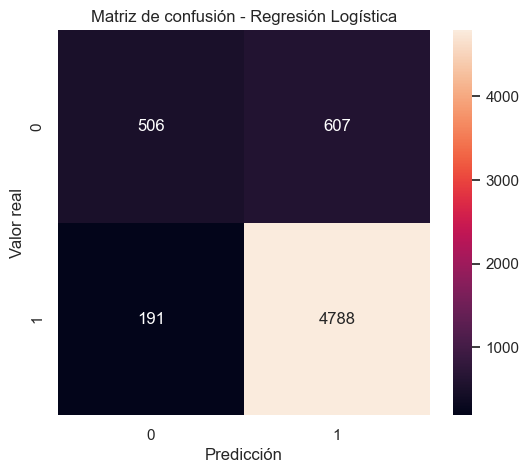

In [59]:
#Matriz de confusion
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))
sns.heatmap(cm_log, annot=True, fmt="d")
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [60]:
#Para observar verdaderos y falsos positivos y negativos


In [63]:
#INTERPRETACIÓN MATRIZ DE CONFUSIÓN:
#506 verdaderos negativos: Casos que realmente no eran de alta satisfacción y el modelo los clasificó correctamente como no alta satisfacción.
#607 falsos positivos: Casos que en realidad no eran alta satisfacción, pero el modelo creyó que sí.
#191 falsos negativos: Casos que sí eran alta satisfacción, pero el modelo los clasificó como no alta satisfacción.

#4788 verdaderos positivos: Casos que realmente eran de alta satisfacción y el modelo predijo correctamente como alta satisfacción.
#Esto es muy importante porque indica que el modelo detecta muy bien los casos positivo

In [64]:
#INTERPRETACIÓN MATRIZ DE CONFUSION PARTE 2
#Concluimos que el modelo detecta muy bien los casos de alta satisfacción ya que tiene muchos verdaderos positivos (4788)
#y sus falsos negativos son relativamente bajos

#DEBILIDAD: El modelo parece tender a clasificar bastante scasos (607) como positivos cuadno no lo son
#¿Por qué? Debido seguramente a que tengo en el dataset una mayor cantidad de positivos es decri de alta satisfacción que de baja y por eso el modelo aprende mejor la clase mayoritaria


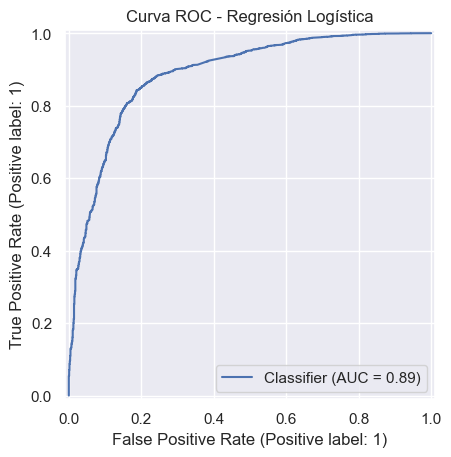

In [61]:
RocCurveDisplay.from_predictions(y_test, y_proba_log)
plt.title("Curva ROC - Regresión Logística")
plt.show()

In [65]:
#INTERPETACIÓN CURVA ROC Y SU AUC
#AUC=0,89 significa que el modelo separa bien ambas clases a distintos umbrales, 
#Es decir, la info del modelo si contiene señal predictiva real
#Por lo que sabemos que variables como el trato, tiempos, SMS y contexto SÍ ayudan aa anticipar la satisfacción

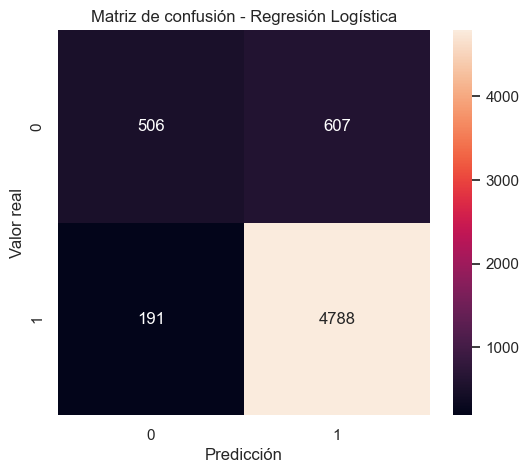

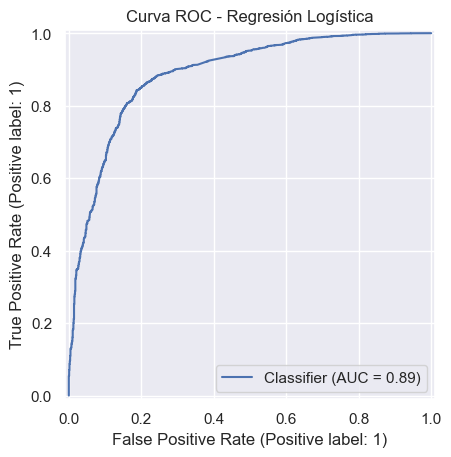

Resultados de la regresión logística guardados


In [62]:
metricas_log.to_excel(tables / "metricas_regresion_logistica.xlsx", index=False)
metricas_log.to_csv(tables / "metricas_regresion_logistica.csv", index=False)

plt.figure(figsize=(6,5))
sns.heatmap(cm_log, annot=True, fmt="d")
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.savefig(graficos / "matriz_confusion_logistica.png", dpi=300, bbox_inches="tight")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_log)
plt.title("Curva ROC - Regresión Logística")
plt.savefig(graficos / "roc_logistica.png", dpi=300, bbox_inches="tight")
plt.show()

print("Resultados de la regresión logística guardados")

In [ ]:
#¿POR QUÉ REGRESIÓN LOGISTICA?
    #1. Necesito un modelo que clasifique 1=alta satisfacción o 0=no alta satisfacción (mi var es binaria)
    #2.Me permite decir con  mayor claridad que otros modelos por ejemplo 
        #si el trato mejora la probabilidad de alta satisfacción sube
        #o si el tiempo de llegada aumenta, la prob de alta satisfacción baja
        #o si SMS es útil, puede estar asociado a mejor experiencia

    #3. Antes de entrenar un modelo más complejo este modelo de regresión lineal me permite interpretarlo y compararlo primero de manra mas clara
    #4. La logistica es muy adecuada si quiero interpretar y ademas predecir
    #5. Me indica: qué probabilidad tiene cada registro de pertenecer a la clase 1, es decir, de ser un caso de alta satisfacción

In [66]:
#CONCLUSIÓN MODELO REGRESIÓN LOGISTICA
#La regresión logística se seleccionó como primer modelo por su adecuación a un problema de clasificación binaria y, especialmente, por su elevada interpretabilidad. En el contexto de este TFG, centrado en comprender y anticipar la satisfacción del solicitante del servicio SAMUR, resultaba esencial disponer de un modelo capaz no solo de predecir, sino también de ofrecer una base explicativa clara sobre cómo variables relacionadas con el tiempo, el trato y la experiencia de comunicación se asocian con la probabilidad de alta satisfacción.

#El modelo se entrenó utilizando variables representativas del proceso de atención telefónica y del contexto del solicitante, tales como el índice de trato total, los tiempos de atención y llegada, la utilidad del SMS, la existencia de segundo contacto, el lugar desde el que se realiza la llamada y variables demográficas básicas. Esta selección responde directamente a la lógica sustantiva del problema planteado: la satisfacción del usuario no depende de un único factor, sino de la combinación entre dimensiones objetivas del servicio y percepciones subjetivas de la experiencia.

#Los resultados obtenidos muestran una capacidad discriminante elevada, con un AUC de 0.89, lo que indica que las variables incluidas contienen una señal predictiva sólida respecto a la satisfacción final. La matriz de confusión revela, además, una buena capacidad para identificar correctamente los casos de alta satisfacción, aunque con mayor dificultad para discriminar la clase minoritaria de no alta satisfacción, algo esperable en un contexto donde predominan valoraciones positivas del servicio.

In [67]:
#Sacamos nombres reales de las variables, y coeficientes del modelo apra interpretar cuales osn mas relevantes apra mi pregutna de investigacion
# Nombres finales de las variables tras el preprocesamiento
feature_names_log = pipeline_log.named_steps["preprocessor"].get_feature_names_out()

# Coeficientes del modelo
coef_log = pipeline_log.named_steps["model"].coef_[0]

# Crear tabla
tabla_coef_log = pd.DataFrame({
    "variable_transformada": feature_names_log,
    "coeficiente": coef_log
})

# Ordenar de mayor a menor impacto absoluto
tabla_coef_log["abs_coef"] = tabla_coef_log["coeficiente"].abs()
tabla_coef_log = tabla_coef_log.sort_values("abs_coef", ascending=False).reset_index(drop=True)

tabla_coef_log.head(20)

,variable_transformada,coeficiente,abs_coef
0,num__op2_no_aplica,2.442839,2.442839
1,num__hubo_segundo_contacto,2.417767,2.417767
2,num__indice_trato_total,1.309214,1.309214
3,cat__genero_hombre,1.147859,1.147859
4,cat__genero_mujer,1.136871,1.136871
5,cat__genero_desconocido,-1.113704,1.113704
6,cat__lugar_llamada_institucion_publica_no_sani...,0.492118,0.492118
7,num__satisfaccion_tiempo_llegada,0.359375,0.359375
8,num__tiempo_llegada_final_min,-0.260532,0.260532
9,cat__lugar_llamada_lugar_trabajo,0.179935,0.179935


In [68]:
#Despues de observar las variables decido eliminar ciertas variables para mi modelo
    
    #1. Elimino op2_no_aplica ya que no mide una percepción ni una caracteristica real del proceso sino una condicion estructural delk cuestionario
    #2. Satisfaccion_tiempo_llegada la elimino ya que esta demasiado cerca conceptualmente d ela variable objetivo ya que es otra satisfaccion declarada por el mismo usuario, no es independiente. Esro podría generar una especie de leakage conceptual.
        #e excluye del modelo principal por representar una valoración subjetiva estrechamente vinculada con la propia satisfacción global. Su inclusión podría reducir la capacidad interpretativa del modelo, al introducir una medida de satisfacción parcial demasiado próxima al objetivo final. Se prioriza así el uso de variables más directamente asociadas al proceso asistencial, como los tiempos, el trato o la experiencia de comunicación.

In [69]:
#REDEFINO LISTA DE VARIABLES
# Variable objetivo
y = df_modelado["satisfaccion_global_binaria"].copy()

# Predictores para logística (modelo interpretable)
features_logistica = [
    "edad",
    "genero",
    "lugar_llamada",
    "asistencia_para_si_mismo",
    "recibio_sms_confirmacion",
    "sms_util",
    "hubo_segundo_contacto",
    "indice_trato_total",
    "tiempo_atencion_final_seg",
    "tiempo_llegada_final_min",
    "anio"
]

# Predictores para modelos avanzados
features_avanzadas = [
    "edad",
    "genero",
    "lugar_llamada",
    "asistencia_para_si_mismo",
    "recibio_sms_confirmacion",
    "sms_util",
    "hubo_segundo_contacto",
    "op1_amabilidad",
    "op1_rapidez",
    "op2_amabilidad",
    "op2_rapidez",
    "indice_trato_op1",
    "indice_trato_op2",
    "indice_trato_total",
    "tiempo_atencion_final_seg",
    "tiempo_llegada_final_min",
    "anio"
]

X_log = df_modelado[features_logistica].copy()
X_adv = df_modelado[features_avanzadas].copy()

print("Shape X_log:", X_log.shape)
print("Shape X_adv:", X_adv.shape)

Shape X_log: (30456, 11)
Shape X_adv: (30456, 17)


In [70]:
#Rehago train/test split
from sklearn.model_selection import train_test_split

X_train_log, X_test_log, y_train, y_test = train_test_split(
    X_log, y, test_size=0.2, random_state=42, stratify=y
)

X_train_adv, X_test_adv, _, _ = train_test_split(
    X_adv, y, test_size=0.2, random_state=42, stratify=y
)

print("Train logística:", X_train_log.shape)
print("Test logística:", X_test_log.shape)
print("Train avanzadas:", X_train_adv.shape)
print("Test avanzadas:", X_test_adv.shape)

Train logística: (24364, 11)
Test logística: (6092, 11)
Train avanzadas: (24364, 17)
Test avanzadas: (6092, 17)


In [72]:
#vuelvo a detectar var numericas y categoricas
num_cols_log = X_train_log.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
cat_cols_log = X_train_log.select_dtypes(include=["object", "string", "category"]).columns.tolist()

num_cols_adv = X_train_adv.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()
cat_cols_adv = X_train_adv.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Logística - numéricas:", num_cols_log)
print("Logística - categóricas:", cat_cols_log)

print("\nAvanzadas - numéricas:", num_cols_adv)
print("Avanzadas - categóricas:", cat_cols_adv)

Logística - numéricas: ['edad', 'asistencia_para_si_mismo', 'recibio_sms_confirmacion', 'sms_util', 'hubo_segundo_contacto', 'indice_trato_total', 'tiempo_atencion_final_seg', 'tiempo_llegada_final_min', 'anio']
Logística - categóricas: ['genero', 'lugar_llamada']

Avanzadas - numéricas: ['edad', 'asistencia_para_si_mismo', 'recibio_sms_confirmacion', 'sms_util', 'hubo_segundo_contacto', 'op1_amabilidad', 'op1_rapidez', 'op2_amabilidad', 'op2_rapidez', 'indice_trato_op1', 'indice_trato_op2', 'indice_trato_total', 'tiempo_atencion_final_seg', 'tiempo_llegada_final_min', 'anio']
Avanzadas - categóricas: ['genero', 'lugar_llamada']


In [73]:
#rehago preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Pipeline logística
num_pipeline_log = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline_log = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_log = ColumnTransformer([
    ("num", num_pipeline_log, num_cols_log),
    ("cat", cat_pipeline_log, cat_cols_log)
])

# Pipeline modelos avanzados
num_pipeline_adv = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline_adv = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_adv = ColumnTransformer([
    ("num", num_pipeline_adv, num_cols_adv),
    ("cat", cat_pipeline_adv, cat_cols_adv)
])

print("Preprocesadores rehechos correctamente")

Preprocesadores rehechos correctamente


In [74]:
#Reentreno REGRESION LOGISTICA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

pipeline_log = Pipeline([
    ("preprocessor", preprocessor_log),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_log.fit(X_train_log, y_train)

y_pred_log = pipeline_log.predict(X_test_log)
y_proba_log = pipeline_log.predict_proba(X_test_log)[:, 1]

metricas_log = pd.DataFrame([{
    "modelo": "Regresion Logistica",
    "accuracy": round(accuracy_score(y_test, y_pred_log), 4),
    "precision": round(precision_score(y_test, y_pred_log), 4),
    "recall": round(recall_score(y_test, y_pred_log), 4),
    "f1_score": round(f1_score(y_test, y_pred_log), 4),
    "roc_auc": round(roc_auc_score(y_test, y_proba_log), 4)
}])

metricas_log

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Regresion Logistica,0.8656,0.8855,0.9596,0.9211,0.8778


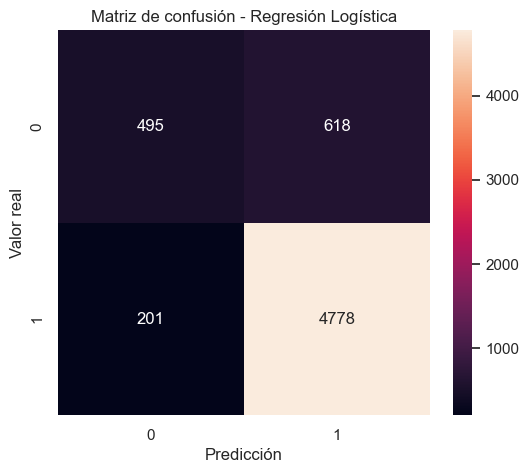

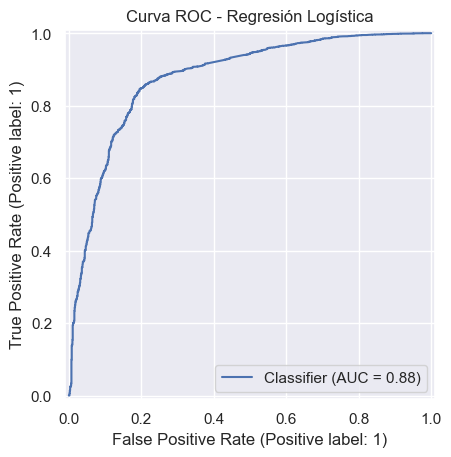

In [75]:
#VUELVO A SACAR MATRIZ DE CONFUSION Y CURVA ROC
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))
sns.heatmap(cm_log, annot=True, fmt="d")
plt.title("Matriz de confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_log)
plt.title("Curva ROC - Regresión Logística")
plt.show()

In [85]:
#El modelo presenta una elevada capacidad para identificar correctamente a los usuarios satisfechos, mientras que muestra mayor dificultad para detectar los casos de insatisfacción. Esto es coherente con la distribución de los datos, donde predominan claramente los casos de satisfacción.
#El modelo presenta una elevada capacidad discriminativa (AUC ≈ 0.88), lo que indica que es capaz de distinguir correctamente entre usuarios satisfechos e insatisfechos en la mayoría de los casos.

In [76]:
#VUELVO A SACAR COEFICIENTES
feature_names_log = pipeline_log.named_steps["preprocessor"].get_feature_names_out()
coef_log = pipeline_log.named_steps["model"].coef_[0]

tabla_coef_log = pd.DataFrame({
    "variable_transformada": feature_names_log,
    "coeficiente": coef_log
})

tabla_coef_log["abs_coef"] = tabla_coef_log["coeficiente"].abs()
tabla_coef_log = tabla_coef_log.sort_values("abs_coef", ascending=False).reset_index(drop=True)

tabla_coef_log.head(20)

,variable_transformada,coeficiente,abs_coef
0,num__indice_trato_total,1.374983,1.374983
1,cat__genero_desconocido,-1.239791,1.239791
2,cat__genero_hombre,1.179953,1.179953
3,cat__genero_mujer,1.170121,1.170121
4,num__tiempo_llegada_final_min,-0.630340,0.630340
5,cat__lugar_llamada_institucion_publica_no_sani...,0.588694,0.588694
6,num__anio,0.289305,0.289305
7,cat__lugar_llamada_desconocido,-0.276866,0.276866
8,cat__lugar_llamada_centro_sanitario,0.209877,0.209877
9,cat__lugar_llamada_lugar_trabajo,0.204883,0.204883


In [81]:
tabla_coef_log.sort_values("coeficiente", ascending=False).head(20)

,variable_transformada,coeficiente,abs_coef
0,num__indice_trato_total,1.374983,1.374983
2,cat__genero_hombre,1.179953,1.179953
3,cat__genero_mujer,1.170121,1.170121
5,cat__lugar_llamada_institucion_publica_no_sani...,0.588694,0.588694
6,num__anio,0.289305,0.289305
8,cat__lugar_llamada_centro_sanitario,0.209877,0.209877
9,cat__lugar_llamada_lugar_trabajo,0.204883,0.204883
10,num__sms_util,0.152696,0.152696
11,cat__lugar_llamada_domicilio,0.125269,0.125269
12,num__edad,0.123221,0.123221


In [82]:
tabla_coef_log.sort_values("coeficiente", ascending=True).head(20)

,variable_transformada,coeficiente,abs_coef
1,cat__genero_desconocido,-1.239791,1.239791
4,num__tiempo_llegada_final_min,-0.630340,0.630340
7,cat__lugar_llamada_desconocido,-0.276866,0.276866
17,cat__lugar_llamada_multiple,-0.065563,0.065563
18,num__tiempo_atencion_final_seg,-0.051916,0.051916
22,cat__lugar_llamada_otro,0.004525,0.004525
21,cat__lugar_llamada_via_publica,0.012577,0.012577
20,num__asistencia_para_si_mismo,0.018845,0.018845
19,num__hubo_segundo_contacto,0.038877,0.038877
16,cat__lugar_llamada_local_comercial,0.091586,0.091586


In [89]:
#Nos muestra qué dimensiones de la experiencia del solicitante están más asociadas con una valoración positiva del servicio.

In [87]:
#indice_trato_total es la variable más relevante y con efecto positivo fuerte

#Coeficiente aproximado: 1.37

#El resultado indica que, manteniendo constantes el resto de variables del modelo, una mejor valoración del trato percibido se asocia de forma clara con una mayor probabilidad de alta satisfacción.
#Este resultado sugiere que el trato interpersonal no es un elemento accesorio, sino una de las dimensiones más determinantes en la construcción de la satisfacción global.

In [90]:
#Los coeficientes asociados a distintas categorías de la variable lugar_llamada sugieren que el contexto desde el que se solicita ayuda no es neutral en la experiencia del usuario. Este resultado apunta a que la satisfacción no depende únicamente de variables internas del proceso asistencial, sino también del entorno situacional en el que se produce la llamada. En un servicio de emergencias, donde la percepción del riesgo, la vulnerabilidad y la urgencia pueden variar significativamente según el contexto, este hallazgo resulta especialmente coherente con la lógica sustantiva del problema estudiado.
#El lugar desde el que se llama puede condicionar:

#el nivel de estrés,
#la urgencia percibida,
#la claridad de la situación,
#la disponibilidad de apoyo de terceros,
#e incluso las expectativas del solicitante.

#Es decir, el contexto de la llamada puede modular la experiencia del usuario y, por tanto, su satisfacción final.

In [91]:
#Recibir SMS y valorarlo como útil se asocia con una mayor probabilidad de alta satisfacción.

In [86]:
#Las variables asociadas al género muestran coeficientes positivos respecto a la categoría de referencia, lo que indica la existencia de diferencias en la distribución de la satisfacción entre grupos. No obstante, estos resultados deben interpretarse con cautela, ya que no implican una relación causal directa, sino una asociación condicionada al resto de variables incluidas en el modelo. En consecuencia, el género debe entenderse más como una variable de contexto y segmentación que como un determinante principal de la satisfacción.

In [93]:
#hubo_segundo_contacto: por qué su efecto pequeño también es informativo

#Sale con coeficiente positivo muy pequeño: alrededor de 0.04
#Este resultado sugiere que la existencia de una segunda interacción no constituye, por sí sola, un factor determinante de la satisfacción global, al menos cuando se controla por otras dimensiones más relevantes como el trato percibido, el contexto de la llamada o la comunicación posterio

In [83]:
#guardo nueva version resultados
metricas_log.to_excel(tables / "metricas_regresion_logistica_v2.xlsx", index=False)
metricas_log.to_csv(tables / "metricas_regresion_logistica_v2.csv", index=False)

tabla_coef_log.to_excel(tables / "coeficientes_regresion_logistica_v2.xlsx", index=False)
tabla_coef_log.to_csv(tables / "coeficientes_regresion_logistica_v2.csv", index=False)

print("Resultados v2 guardados")

Resultados v2 guardados


In [84]:
#ntes de consolidar el modelo logístico final se realizó una revisión crítica de las variables incluidas inicialmente como predictores. Esta revisión no se orientó únicamente al rendimiento predictivo, sino también a la coherencia analítica del modelo con la pregunta de investigación del TFG.

#En este proceso se decidió excluir la variable op2_no_aplica, al considerar que no representa una dimensión sustantiva de la experiencia del solicitante, sino una condición estructural del cuestionario relativa a la aplicabilidad de la segunda interacción. Su inclusión podía inducir al modelo a capturar patrones derivados del diseño de la encuesta en lugar de relaciones reales entre el proceso asistencial y la satisfacción.

#Asimismo, se excluyó satisfaccion_tiempo_llegada, por tratarse de una valoración subjetiva estrechamente vinculada a la propia satisfacción global, lo que podía reducir la capacidad explicativa del modelo e introducir una medida parcial de satisfacción demasiado próxima al objetivo final. En coherencia con el propósito del trabajo, se optó por priorizar variables más directamente relacionadas con el proceso de atención, como tiempos, trato, comunicación y contexto.

#Por el contrario, la variable hubo_segundo_contacto se mantuvo en el modelo al considerarse una característica real del proceso de atención telefónica, potencialmente asociada a la complejidad del caso o a un tipo de interacción distinto con el servicio, y por tanto con posible valor explicativo.

In [94]:
#MODELO 2: RANDOM FOREST
#Con este modelo quiero comprobar si las relaciones entre trato, tiempo, contexto y satisfacción son más conmplejas de lo que un modelo lineal puede capturar

#¿POR QUÉ RANDOM FOREST?
#Porque la satisfacción del solicitante puede depender de combinaciones complejas entre tiempos, calidad del trato, utilidad de la comunicación y contexto de la llamada.
    #En el SAMUR es razonable pensar que un aumento pequeño en el tiempo no afecte igual en todos los casos
    #El buen trato pueda compensar parcialmente tiempos peores
    #EL efecto SMS dependa del contexto de la llamada
    #O determinadas combinaciones de variables generen patrones que la logistica no recoge bien

In [95]:
#Importo lo necesario para el modelo
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

In [97]:
#PIPELINE RANDOM FOREST
#Utilizo n_estimators=300 para que el modelo sea estable y robusto (muchos árboles)
#random_state=42 porque garantiza reproducibilidad
#class_weight="balanced" porque en mi var objetivo predonminar los casos de alta satisfaccion y con este ajuste intento que mi modelo no ignore la clase minoritaria que seria la minoria de no alta satisfacción
pipeline_rf = Pipeline([
    ("preprocessor", preprocessor_adv),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

pipeline_rf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [98]:
#ENtreno el modelo
pipeline_rf.fit(X_train_adv, y_train)
print("Random Forest entrenado correctamente")

Random Forest entrenado correctamente


In [99]:
#Predicciones RANDOM FOREST
y_pred_rf = pipeline_rf.predict(X_test_adv)
y_proba_rf = pipeline_rf.predict_proba(X_test_adv)[:, 1]

print("Predicciones Random Forest hechas")

Predicciones Random Forest hechas


In [100]:
#CALCULO MEDIDAS
metricas_rf = pd.DataFrame([{
    "modelo": "Random Forest",
    "accuracy": round(accuracy_score(y_test, y_pred_rf), 4),
    "precision": round(precision_score(y_test, y_pred_rf), 4),
    "recall": round(recall_score(y_test, y_pred_rf), 4),
    "f1_score": round(f1_score(y_test, y_pred_rf), 4),
    "roc_auc": round(roc_auc_score(y_test, y_proba_rf), 4)
}])

metricas_rf

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,0.8726,0.925,0.9187,0.9218,0.865


In [101]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.65      0.67      0.66      1113
           1       0.92      0.92      0.92      4979

    accuracy                           0.87      6092
   macro avg       0.79      0.79      0.79      6092
weighted avg       0.87      0.87      0.87      6092



In [106]:
#La regresión logística presenta un rendimiento ligeramente superior en términos de AUC, lo que indica una mejor capacidad discriminativa global. Además, al tratarse de un modelo más interpretable, permite comprender de forma más clara la relación entre las variables del proceso y la satisfacción del usuario.

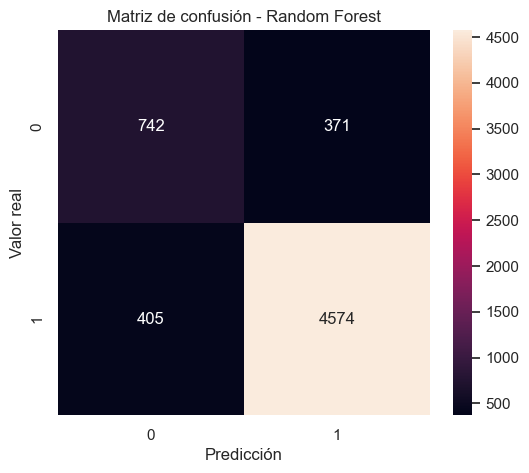

In [102]:
#MATRIZ DE CONFUSION
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [109]:
##El modelo Random Forest muestra una mejora en la identificación de usuarios no satisfechos en comparación con la regresión logística, lo que sugiere que es capaz de capturar patrones más complejos asociados a la insatisfacción. No obstante, esta mejora se produce a costa de una ligera pérdida de capacidad discriminativa globa
#RANDOM FOREST detecta mejor nos NO satisfechos (clase 0) 

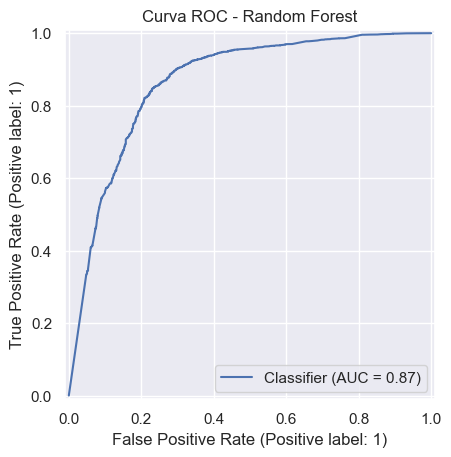

In [103]:
#CURVA ROC
RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("Curva ROC - Random Forest")
plt.show()

In [ ]:
#El modelo presenta una buena capacidad de discriminación, aunque ligeramente inferior a la regresión logística, lo que indica que la complejidad añadida del modelo no se traduce en una mejora significativa del rendimiento global.
#AUC=0,87 frente AUC de regresion logistica=0,88

In [104]:
#SACO IMPORTANACIA DE LAS VARIABLES
#En este modelo interpreto los coeficientes en terminos de importancia relativa
#Es decir, qué variables usa más el modelo para separar clases
feature_names_adv = pipeline_rf.named_steps["preprocessor"].get_feature_names_out()
importances_rf = pipeline_rf.named_steps["model"].feature_importances_

tabla_importancias_rf = pd.DataFrame({
    "variable_transformada": feature_names_adv,
    "importancia": importances_rf
}).sort_values("importancia", ascending=False).reset_index(drop=True)

tabla_importancias_rf.head(20)

,variable_transformada,importancia
0,num__edad,0.185370
1,num__indice_trato_total,0.119764
2,cat__genero_desconocido,0.119097
3,num__indice_trato_op1,0.099099
4,num__op1_rapidez,0.081951
5,num__tiempo_llegada_final_min,0.062434
6,num__op1_amabilidad,0.061478
7,num__tiempo_atencion_final_seg,0.046482
8,cat__genero_mujer,0.033396
9,cat__genero_hombre,0.028867


In [110]:
#Cone el modelo de RANDOM FOREST detectamos un patron oculto de la edad que tiene un peso mucho mayuor que el que parecía en la logísrtica
#Esto quiere decir que la realcion entre edad y satisfaccion NO es lineal


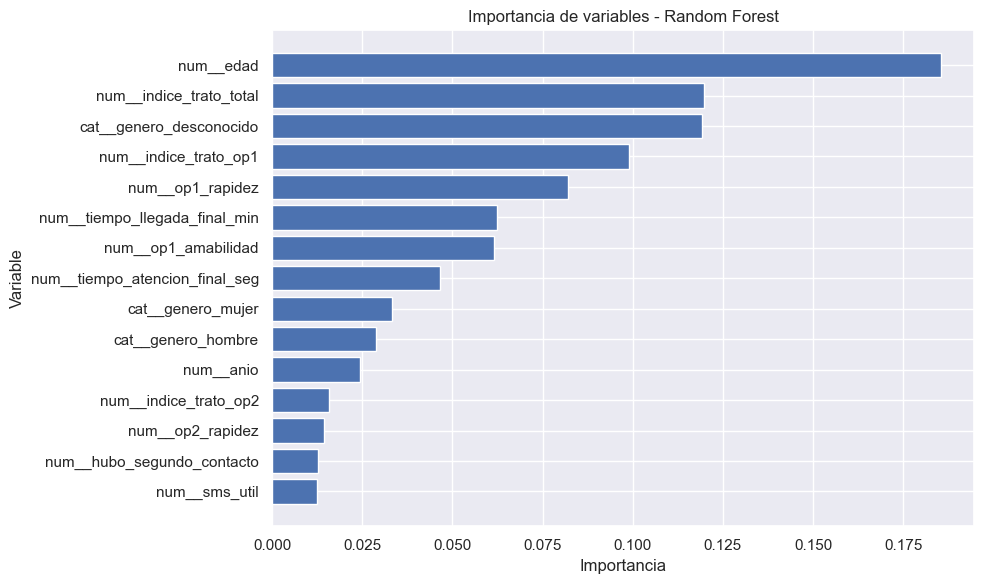

In [105]:
#GRAFICO VAR IMPORTANTES
top_rf = tabla_importancias_rf.head(15).sort_values("importancia")

plt.figure(figsize=(10,6))
plt.barh(top_rf["variable_transformada"], top_rf["importancia"])
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [ ]:
metricas_rf.to_excel(tables / "metricas_random_forest.xlsx", index=False)
metricas_rf.to_csv(tables / "metricas_random_forest.csv", index=False)

tabla_importancias_rf.to_excel(tables / "importancias_random_forest.xlsx", index=False)
tabla_importancias_rf.to_csv(tables / "importancias_random_forest.csv", index=False)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.savefig(graficos / "matriz_confusion_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("Curva ROC - Random Forest")
plt.savefig(graficos / "roc_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

top_rf = tabla_importancias_rf.head(15).sort_values("importancia")
plt.figure(figsize=(10,6))
plt.barh(top_rf["variable_transformada"], top_rf["importancia"])
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(graficos / "importancia_variables_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

print("Resultados Random Forest guardados")

In [111]:
#Los resultados obtenidos mediante Random Forest confirman que la satisfacción del solicitante en el servicio SAMUR no depende de un único factor, sino de una combinación de variables relacionadas con el trato, los tiempos de atención y las características del usuario. En particular, la relevancia de la edad sugiere que la percepción del servicio varía entre distintos perfiles de usuarios, lo que pone de manifiesto la necesidad de adoptar un enfoque más segmentado en la mejora del servicio.

In [112]:
#La comparación entre modelos revela que, aunque existen relaciones no lineales en los datos, la regresión logística es capaz de capturar la mayor parte del comportamiento del fenómeno, lo que sugiere que la satisfacción puede explicarse en gran medida mediante relaciones relativamente estables entre variables clave como el trato y el tiempo.

In [113]:
#DESTACAR: GENERO_DESCONOCIDO ALTO EXPLICACIÓN
#la presencia de esta variable como relevante sugiere posibles efectos derivados de la calidad del dato

In [ ]:
#GENERO_DESCONOCIDO EXPLICACIÓN 2:
#La relevancia de la categoría genero_desconocido en el modelo no debe interpretarse como un efecto sustantivo del género, sino como un indicador de que los registros con información no declarada o no disponible presentan un patrón diferenciado en el conjunto de datos. Este resultado puede reflejar efectos indirectos asociados a la calidad del registro, al contexto de la llamada o a características no observadas del proceso, por lo que su interpretación debe realizarse con cautela.
#En la variable genero se identificaron categorías homogéneas (hombre, mujer) y un conjunto de valores ausentes o no informados, que se agruparon bajo la categoría desconocido. Esta decisión responde a un criterio de rigor metodológico: dado que no existe información suficiente para inferir de manera fiable el género real del solicitante, imputar artificialmente dichos registros como hombre o mujer habría supuesto introducir supuestos no observables y alterar la estructura real del dataset.

In [114]:
#En random forest el SMS pierde importancia. El impacto del SMS podría estar condicionado por otras variables, perdiendo relevancia cuando se consideran interacciones más complejas

In [115]:
#La diferencia en la relevancia de variables entre modelos refleja la distinta capacidad de cada técnica para capturar patrones en los datos. Mientras que la regresión logística identifica relaciones lineales claras entre variables y la satisfacción, Random Forest es capaz de detectar interacciones y efectos no lineales, lo que explica la mayor importancia de variables como la edad en este modelo.

In [119]:
#TABLA COMPARATIVA
tabla_metricas_modelos = pd.concat([
    metricas_log,
    metricas_rf
], ignore_index=True)

tabla_metricas_modelos

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Regresion Logistica,0.8656,0.8855,0.9596,0.9211,0.8778
1,Random Forest,0.8726,0.9250,0.9187,0.9218,0.8650


In [120]:
#GUARDO TABLA
tabla_metricas_modelos.to_excel(tables / "comparativa_modelos_supervisados.xlsx", index=False)
tabla_metricas_modelos.to_csv(tables / "comparativa_modelos_supervisados.csv", index=False)

print("Tabla comparativa guardada")

Tabla comparativa guardada


<Figure size 1000x600 with 0 Axes>

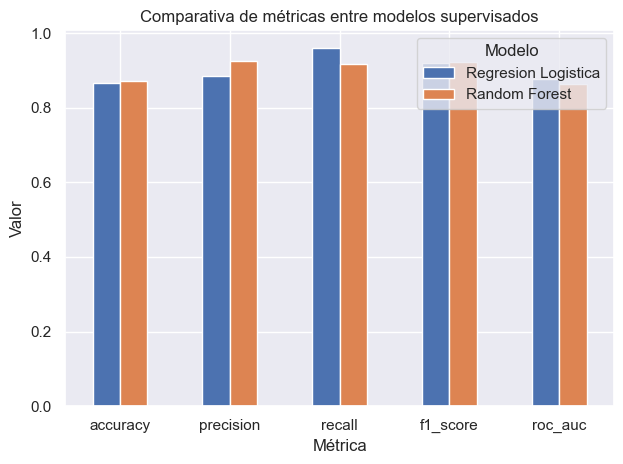

In [121]:
#grafico comparativo memoria

tabla_metricas_plot = tabla_metricas_modelos.set_index("modelo").T

plt.figure(figsize=(10,6))
tabla_metricas_plot.plot(kind="bar")
plt.title("Comparativa de métricas entre modelos supervisados")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.tight_layout()
plt.savefig(graficos / "comparativa_metricas_modelos.png", dpi=300, bbox_inches="tight")
plt.show()

In [122]:
#CONCLUSION MODELO:
#Con el fin de contrastar empíricamente distintas aproximaciones al problema de predicción de la satisfacción, se entrenaron dos modelos supervisados: una regresión logística como modelo base interpretable y un Random Forest como modelo avanzado capaz de capturar relaciones no lineales.

#La comparación de resultados muestra que ambos modelos alcanzan un buen rendimiento global, aunque la regresión logística presenta una capacidad discriminativa ligeramente superior en términos de AUC, mientras que Random Forest mejora parcialmente la identificación de la clase minoritaria. No obstante, dicha mejora no resulta suficientemente amplia como para compensar la pérdida de interpretabilidad del modelo.

#En consecuencia, se selecciona la regresión logística como modelo principal del trabajo, al ofrecer un equilibrio más adecuado entre capacidad predictiva, trazabilidad e interpretación sustantiva de los factores que influyen en la satisfacción del solicitante. Random Forest se conserva como modelo de contraste, aportando evidencia adicional sobre la existencia de relaciones no lineales y reforzando la robustez del análisis.

In [123]:
#TABLA RESUMEN 
decision_modelos = pd.DataFrame([
    {
        "modelo": "Regresion Logistica",
        "rol_en_tfg": "modelo principal",
        "fortaleza_principal": "alta interpretabilidad y buen AUC",
        "limitacion_principal": "menor flexibilidad ante no linealidades"
    },
    {
        "modelo": "Random Forest",
        "rol_en_tfg": "modelo comparativo",
        "fortaleza_principal": "captura relaciones complejas y mejora la clase minoritaria",
        "limitacion_principal": "menor interpretabilidad y sin mejora clara en AUC"
    }
])

decision_modelos

,modelo,rol_en_tfg,fortaleza_principal,limitacion_principal
0,Regresion Logistica,modelo principal,alta interpretabilidad y buen AUC,menor flexibilidad ante no linealidades
1,Random Forest,modelo comparativo,captura relaciones complejas y mejora la clase...,menor interpretabilidad y sin mejora clara en AUC


In [124]:
#GUARDO
decision_modelos.to_excel(tables / "decision_final_modelos.xlsx", index=False)
decision_modelos.to_csv(tables / "decision_final_modelos.csv", index=False)

print("Tabla de decisión final guardada")

Tabla de decisión final guardada


In [133]:
#CLUSTERING PARA RESPONDER A QUE TIPOS DE EXPERIENCIAS/USUARIOS EXISTEN DENTRO DEL SERVICIO COMO PASO HACIA EL ANALISIS DEL NEGOCIO
#selecciono variables que describen la experiecia del servicio
# CLUSTERING PARA RESPONDER A QUÉ TIPOS DE EXPERIENCIAS/USUARIOS EXISTEN DENTRO DEL SERVICIO

# Variables para clustering: describen la experiencia del servicio
variables_clustering = [
    "edad",
    "tiempo_llegada_final_min",
    "tiempo_atencion_final_seg",
    "indice_trato_total",
    "satisfaccion_global",
    "sms_util"
]

# Partimos del dataset analítico final del notebook de análisis
df_cluster = df_modelado[variables_clustering].copy()

# Convertimos todo a numérico por seguridad
for col in df_cluster.columns:
    df_cluster[col] = pd.to_numeric(df_cluster[col], errors="coerce")

# Eliminamos filas con nulos en estas variables
df_cluster = df_cluster.dropna().copy()

print("Shape tras dropna:", df_cluster.shape)
print("\nTipos:")
print(df_cluster.dtypes)
print("\nNulos:")
print(df_cluster.isna().sum())

Shape tras dropna: (20963, 6)

Tipos:
edad                         float64
tiempo_llegada_final_min     float64
tiempo_atencion_final_seg    float64
indice_trato_total           float64
satisfaccion_global          float64
sms_util                     float64
dtype: object

Nulos:
edad                         0
tiempo_llegada_final_min     0
tiempo_atencion_final_seg    0
indice_trato_total           0
satisfaccion_global          0
sms_util                     0
dtype: int64


In [134]:
#El objetivo del clustering no es predecir la varr objetivo, sino descubrir perfiles reales de experiencia que nos ayudaran al final a enfocarlo al analisis del negocio
#Para este caso tiene mas sentido trabajar con registros completos para las variables (tiempo, trato, satisfaccion, utlidad sms y edad) aunqeu pierda algo de muestra
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(df_cluster)

print("Shape X_cluster_scaled:", X_cluster_scaled.shape)
print("¿Hay NaN?", np.isnan(X_cluster_scaled).any())
print("¿Hay inf?", np.isinf(X_cluster_scaled).any())

Shape X_cluster_scaled: (20963, 6)
¿Hay NaN? False
¿Hay inf? False


In [131]:
#Se aplicó una estandarización previa de las variables para evitar que aquellas medidas en escalas más altas, especialmente los tiempos, dominaran el proceso de agrupación. Esta decisión resulta fundamental en el presente TFG, dado que el interés no se centra únicamente en la dimensión temporal del servicio, sino en identificar perfiles de experiencia construidos a partir de la combinación entre tiempo, trato, satisfacción y utilidad percibida.

In [136]:
#He convertidoa numerico porque en clustering no queiro ambiguedad de tipos y necesito que todas las variables uaadas para medir distancias sean numericas
#dropna() porque KMeans trabaja con distancias euclídeas y los nulos rompen esa lógica.
#Escalado: Porque si no, los tiempos dominarían la segmentación y no estarías detectando perfiles de experiencia completos, sino casi solo perfiles por magnitud temporal.

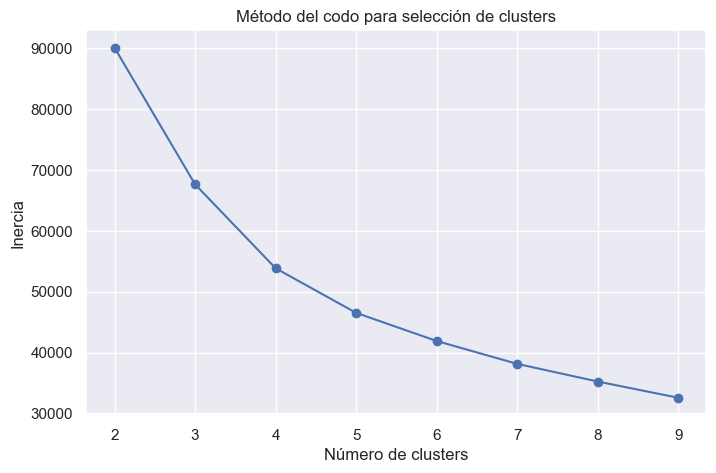

In [135]:
#ELIJO NUMERO DE CLUSTERS
#El número de clusters se seleccionó mediante el método del codo, analizando la evolución de la inercia al aumentar progresivamente el número de grupos. Este criterio permite identificar el punto a partir del cual incrementar la segmentación deja de aportar mejoras sustanciales en la compactación interna de los clusters, favoreciendo así una solución interpretable y no arbitraria.
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker="o")
plt.title("Método del codo para selección de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

In [137]:
#La elección del numero de clusters es 4 
#El número óptimo de clusters se determinó mediante el método del codo, analizando la evolución de la inercia al incrementar el número de grupos. Tal y como se observa en la Figura X, la reducción de la inercia es significativa hasta k=4, a partir de donde la mejora comienza a estabilizarse.

#Esto indica que dividir los datos en más de cuatro grupos no aporta una mejora sustancial en la cohesión interna de los clusters, introduciendo complejidad innecesaria sin un incremento relevante en la calidad de la segmentación.

In [138]:
#Aplico Kmeans definitivo
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans_final.fit_predict(X_cluster_scaled)

df_cluster.head()

,edad,tiempo_llegada_final_min,tiempo_atencion_final_seg,indice_trato_total,satisfaccion_global,sms_util,cluster
0,34.0,5.0,10.0,6.5,8.0,0.0,2
2,55.0,5.0,10.0,10.0,10.0,1.0,1
3,70.0,15.0,10.0,10.0,10.0,1.0,1
4,49.0,20.0,20.0,8.0,8.0,1.0,1
5,54.0,5.0,40.0,9.0,10.0,1.0,1


In [139]:
resumen_clusters = df_cluster.groupby("cluster").mean().round(2)
resumen_clusters

,edad,tiempo_llegada_final_min,tiempo_atencion_final_seg,indice_trato_total,satisfaccion_global,sms_util
cluster,,,,,,
0,42.11,17.65,76.46,4.76,4.58,0.79
1,44.47,9.38,14.17,9.46,9.39,1.00
2,42.75,17.27,72.66,8.75,8.48,0.00
3,45.80,30.01,182.98,9.48,9.43,1.00


In [140]:
#1 insatisfecho
#2 muy satisfecho
#3 satisfecho pero sin utilidad de SMS
#4 muy buen trato y satisfacción alta, pero tiempos muy largos

#Demuestra que la satisfacción no depende de una sola variable, sino de una combinación de:

    #trato
    #tiempos
    #comunicación
    #y perfil del usuario

In [141]:
#esos perfiles muestran que:

#el trato tiene un papel central,
#la utilidad del SMS no actúa igual en todos los usuarios,
#y el tiempo, aunque importante, no determina por sí solo la satisfacción.

In [142]:
#MAPA CLUSTERS
mapa_clusters = {
    0: "Criticamente_insatisfechos",
    1: "Experiencia_optima",
    2: "Satisfechos_sin_sms",
    3: "Satisfechos_pese_espera"
}

df_cluster["cluster_nombre"] = df_cluster["cluster"].map(mapa_clusters)

df_cluster[["cluster", "cluster_nombre"]].drop_duplicates().sort_values("cluster")

,cluster,cluster_nombre
15,0,Criticamente_insatisfechos
2,1,Experiencia_optima
0,2,Satisfechos_sin_sms
15230,3,Satisfechos_pese_espera


In [146]:

# guardar resumen numérico de clusters
resumen_clusters.to_excel(tables / "clustering_resumen_clusters.xlsx", index=True)
resumen_clusters.to_csv(tables / "clustering_resumen_clusters.csv", index=True)

print("Resumen de clusters guardado")

Resumen de clusters guardado


In [147]:
# guardar dataset de clustering con la etiqueta asignada
df_cluster.to_excel(tables / "clustering_dataset_etiquetado.xlsx", index=False)
df_cluster.to_csv(tables / "clustering_dataset_etiquetado.csv", index=False)

print("Dataset de clustering etiquetado guardado")

Dataset de clustering etiquetado guardado


In [148]:
mapa_clusters = {
    0: "Criticamente_insatisfechos",
    1: "Experiencia_optima",
    2: "Satisfechos_sin_sms",
    3: "Satisfechos_pese_espera"
}

df_cluster["cluster_nombre"] = df_cluster["cluster"].map(mapa_clusters)

df_cluster[["cluster", "cluster_nombre"]].drop_duplicates().sort_values("cluster")

,cluster,cluster_nombre
15,0,Criticamente_insatisfechos
2,1,Experiencia_optima
0,2,Satisfechos_sin_sms
15230,3,Satisfechos_pese_espera


In [149]:
df_cluster.to_excel(tables / "clustering_dataset_etiquetado_con_nombres.xlsx", index=False)
df_cluster.to_csv(tables / "clustering_dataset_etiquetado_con_nombres.csv", index=False)

print("Dataset de clustering con nombres guardado")

Dataset de clustering con nombres guardado


In [150]:
interpretacion_clusters = pd.DataFrame([
    {
        "cluster": 0,
        "nombre": "Criticamente_insatisfechos",
        "interpretacion": "Usuarios con baja satisfacción y bajo trato percibido, donde la experiencia negativa parece explicarse sobre todo por la mala calidad de la interacción."
    },
    {
        "cluster": 1,
        "nombre": "Experiencia_optima",
        "interpretacion": "Usuarios con tiempos bajos, trato excelente, alta satisfacción y utilidad total del SMS. Representan la experiencia ideal del servicio."
    },
    {
        "cluster": 2,
        "nombre": "Satisfechos_sin_sms",
        "interpretacion": "Usuarios con satisfacción alta y buen trato, pero sin utilidad percibida del SMS. La experiencia positiva no depende en este grupo de la comunicación posterior."
    },
    {
        "cluster": 3,
        "nombre": "Satisfechos_pese_espera",
        "interpretacion": "Usuarios con tiempos elevados pero trato excelente y alta satisfacción, lo que sugiere un efecto compensador del trato y la comunicación sobre la espera."
    }
])

interpretacion_clusters

,cluster,nombre,interpretacion
0,0,Criticamente_insatisfechos,Usuarios con baja satisfacción y bajo trato pe...
1,1,Experiencia_optima,"Usuarios con tiempos bajos, trato excelente, a..."
2,2,Satisfechos_sin_sms,"Usuarios con satisfacción alta y buen trato, p..."
3,3,Satisfechos_pese_espera,Usuarios con tiempos elevados pero trato excel...


In [151]:
interpretacion_clusters.to_excel(tables / "clustering_interpretacion_clusters.xlsx", index=False)
interpretacion_clusters.to_csv(tables / "clustering_interpretacion_clusters.csv", index=False)

print("Interpretación de clusters guardada")

Interpretación de clusters guardada


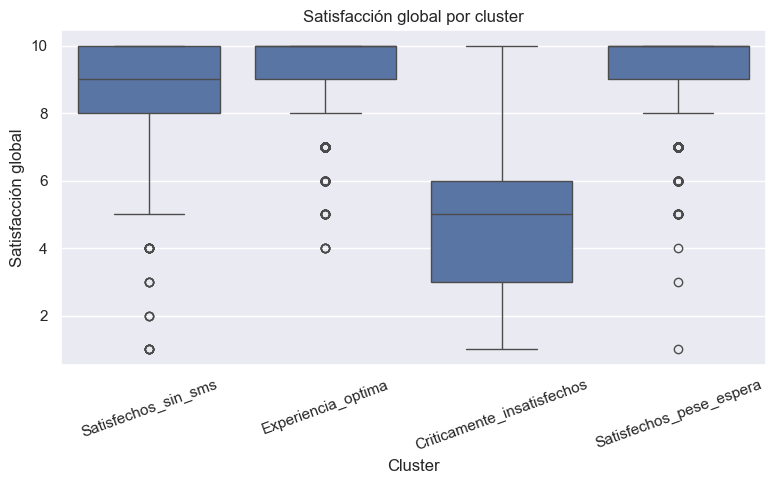

In [152]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cluster_nombre", y="satisfaccion_global", data=df_cluster)
plt.title("Satisfacción global por cluster")
plt.xlabel("Cluster")
plt.ylabel("Satisfacción global")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(graficos / "clustering_satisfaccion_por_cluster.png", dpi=300, bbox_inches="tight")
plt.show()

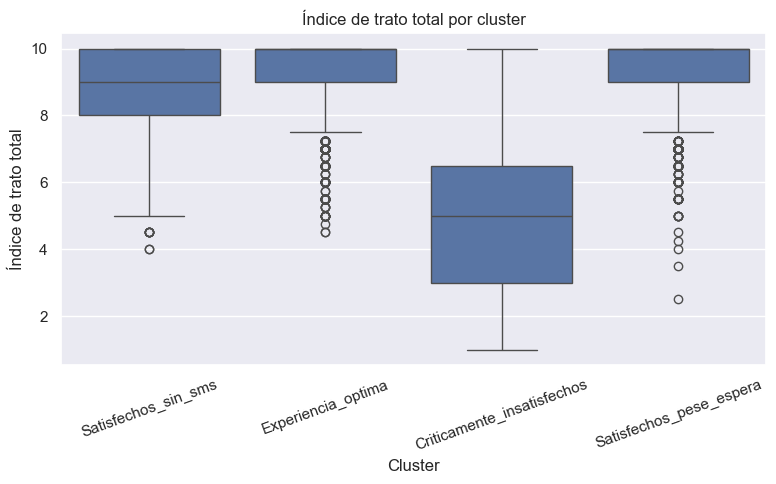

In [153]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cluster_nombre", y="indice_trato_total", data=df_cluster)
plt.title("Índice de trato total por cluster")
plt.xlabel("Cluster")
plt.ylabel("Índice de trato total")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(graficos / "clustering_trato_por_cluster.png", dpi=300, bbox_inches="tight")
plt.show()

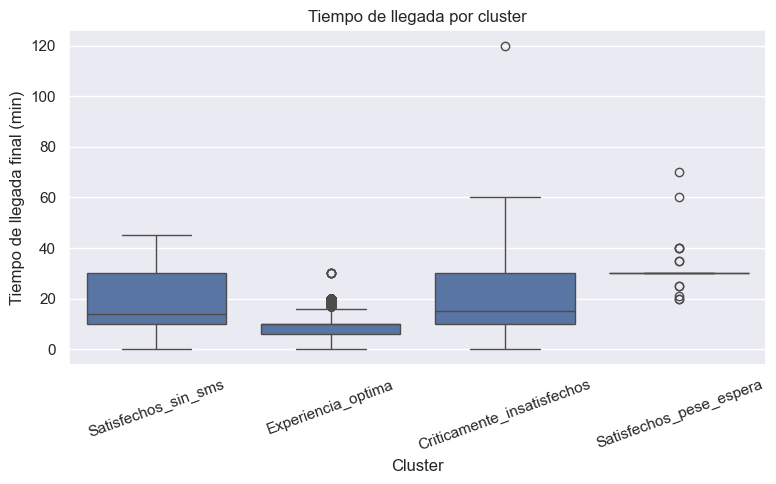

In [154]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cluster_nombre", y="tiempo_llegada_final_min", data=df_cluster)
plt.title("Tiempo de llegada por cluster")
plt.xlabel("Cluster")
plt.ylabel("Tiempo de llegada final (min)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(graficos / "clustering_tiempo_llegada_por_cluster.png", dpi=300, bbox_inches="tight")
plt.show()

In [156]:
#ESQUEMA DE VALIDACION CRUZADA
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [158]:
#stratifiedKfold mantiene proporcion de satisfechos/no satisfechos
#n_splits=5 elección estándar y robusya
#shuffle=true evita depender del orden de los datos
#random_state=42 garantiza reproducibilidad

In [160]:
#VALIDACOIN CRUZADA PARA REGRESION LOGISTGICA ROC-AUC
cv_auc_log = cross_val_score(
    pipeline_log,
    X_log,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("ROC-AUC CV Logística:", cv_auc_log)
print("Media:", round(cv_auc_log.mean(), 4))
print("Desv. típica:", round(cv_auc_log.std(), 4))

ROC-AUC CV Logística: [0.88445758 0.8878343  0.88235451 0.88436208 0.88870419]
Media: 0.8855
Desv. típica: 0.0024


In [161]:
#VALIDACION CRUZADA PARA REGRESION LOGISTICA F1
cv_f1_log = cross_val_score(
    pipeline_log,
    X_log,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("F1 CV Logística:", cv_f1_log)
print("Media:", round(cv_f1_log.mean(), 4))
print("Desv. típica:", round(cv_f1_log.std(), 4))

F1 CV Logística: [0.92158556 0.92144374 0.91954685 0.92328398 0.92442476]
Media: 0.9221
Desv. típica: 0.0017


In [162]:
#VALIDACION CRUZADA PARA RANDOM FOREST ROC-AUC
cv_auc_rf = cross_val_score(
    pipeline_rf,
    X_adv,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("ROC-AUC CV Random Forest:", cv_auc_rf)
print("Media:", round(cv_auc_rf.mean(), 4))
print("Desv. típica:", round(cv_auc_rf.std(), 4))

ROC-AUC CV Random Forest: [0.87931008 0.87683622 0.88186701 0.87704742 0.87793037]
Media: 0.8786
Desv. típica: 0.0019


In [163]:
#VALIDACION CRUZADA PARA RANDOM FOREST F1
cv_f1_rf = cross_val_score(
    pipeline_rf,
    X_adv,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("F1 CV Random Forest:", cv_f1_rf)
print("Media:", round(cv_f1_rf.mean(), 4))
print("Desv. típica:", round(cv_f1_rf.std(), 4))

F1 CV Random Forest: [0.9245283  0.92329346 0.92469423 0.92435108 0.924729  ]
Media: 0.9243
Desv. típica: 0.0005


In [164]:
tabla_cv = pd.DataFrame([
    {
        "modelo": "Regresion Logistica",
        "cv_auc_mean": round(cv_auc_log.mean(), 4),
        "cv_auc_std": round(cv_auc_log.std(), 4),
        "cv_f1_mean": round(cv_f1_log.mean(), 4),
        "cv_f1_std": round(cv_f1_log.std(), 4)
    },
    {
        "modelo": "Random Forest",
        "cv_auc_mean": round(cv_auc_rf.mean(), 4),
        "cv_auc_std": round(cv_auc_rf.std(), 4),
        "cv_f1_mean": round(cv_f1_rf.mean(), 4),
        "cv_f1_std": round(cv_f1_rf.std(), 4)
    }
])

tabla_cv

,modelo,cv_auc_mean,cv_auc_std,cv_f1_mean,cv_f1_std
0,Regresion Logistica,0.8855,0.0024,0.9221,0.0017
1,Random Forest,0.8786,0.0019,0.9243,0.0005


In [165]:
#guardo tabla
tabla_cv.to_excel(tables / "validacion_cruzada_modelos.xlsx", index=False)
tabla_cv.to_csv(tables / "validacion_cruzada_modelos.csv", index=False)

print("Tabla de validación cruzada guardada")

Tabla de validación cruzada guardada


In [166]:
#La validación cruzada se incorporó con el objetivo de comprobar la estabilidad del rendimiento de los modelos más allá de una única partición entrenamiento-test. Esta decisión aporta robustez metodológica al análisis, permitiendo verificar que las conclusiones obtenidas no dependen de una división concreta del dataset, sino que se mantienen de forma consistente sobre distintas particiones de los datos.

In [168]:
#AJUSTE DE HIPERPARAMETROS EN RADNOM FOREST
#Random FOrest es el modelo más flexible frente e a la logistica, por eso tiene sentido comporbar si su rendimiento mejora cuando ajusto 
    #nº arboles
    #profunididad
    #tamaño min de hojas
#ESTO NOS SIRVE PARA JJUSTIFICAR LA DECISION FINAL DEL MODELO ELEGIDO utilizando RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV
param_dist_rf = {
    "model__n_estimators": [100, 200, 300, 500], #mas arboles puedan mejorar estabilidad
    "model__max_depth": [5, 10, 15, 20, None], #controla complejidad del arbol
    "model__min_samples_split": [2, 5, 10], #evita divisiones demasiado agresivas
    "model__min_samples_leaf": [1, 2, 4], #controla tamaño min de hoja y reduce sobreajuste
    "model__max_features": ["sqrt", "log2", None] #controla cuantas variables ve cada arbol en cada division
}

In [169]:
random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist_rf,
    n_iter=15,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

In [170]:
#entreno busqueda
random_search_rf.fit(X_adv, y)

print("Mejores parámetros:", random_search_rf.best_params_)
print("Mejor ROC-AUC CV:", round(random_search_rf.best_score_, 4))

Mejores parámetros: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 5}
Mejor ROC-AUC CV: 0.8294


In [171]:
#resultdos del ajuste
tabla_tuning_rf = pd.DataFrame([{
    "mejor_n_estimators": random_search_rf.best_params_["model__n_estimators"],
    "mejor_max_depth": random_search_rf.best_params_["model__max_depth"],
    "mejor_min_samples_split": random_search_rf.best_params_["model__min_samples_split"],
    "mejor_min_samples_leaf": random_search_rf.best_params_["model__min_samples_leaf"],
    "mejor_max_features": random_search_rf.best_params_["model__max_features"],
    "mejor_roc_auc_cv": round(random_search_rf.best_score_, 4)
}])

tabla_tuning_rf

,mejor_n_estimators,mejor_max_depth,mejor_min_samples_split,mejor_min_samples_leaf,mejor_max_features,mejor_roc_auc_cv
0,300,5,5,1,sqrt,0.8294


In [172]:
tabla_tuning_rf.to_excel(tables / "tuning_random_forest.xlsx", index=False)
tabla_tuning_rf.to_csv(tables / "tuning_random_forest.csv", index=False)

print("Tabla de tuning de Random Forest guardada")

Tabla de tuning de Random Forest guardada


#RESULTADOS AJUSTE EXPLICACIÓN
#NO NECESITO MODELO MÁS COMPLEJO PARA EXPLICAR EL PROBLEMA (roc_auc=0,8294 y antes roc_auc=0,86-0,87)
#El ajuste de hiperparámetros del modelo Random Forest no produce una mejora sustancial en el rendimiento respecto a la configuración inicial. Esto sugiere que la capacidad predictiva del modelo ya estaba próxima a su óptimo bajo una configuración estándar, y que aumentar su complejidad no aporta beneficios significativos en este contexto.

In [173]:
#A pesar de aplicar un proceso de optimización de hiperparámetros sobre el modelo Random Forest, no se observa una mejora significativa en su rendimiento respecto a la configuración inicial. Este resultado sugiere que el modelo no requiere un alto nivel de complejidad para capturar los patrones presentes en los datos.

#En este contexto, y considerando que el objetivo del trabajo no es únicamente predecir, sino también interpretar los factores que influyen en la satisfacción del usuario, la regresión logística se mantiene como la opción más adecuada, al ofrecer un equilibrio óptimo entre rendimiento y capacidad explicativa.